# Chapter 3: Spectral Sequences and Applications

**Source Span.** Bott-Tu, *Differential Forms in Algebraic Topology*, Chapter III, printed pages and PDF labels `154-265`. Source extraction note: the Poppler `pdftotext` read used the assigned labels and an extended physical-page window to include the end of Section 19, because the physical PDF pages are offset from printed labels.

**Chapter Goal.** Turn the chapter's main mechanism into inspectable data: a filtered complex gives pages, page differentials move with a predictable bidegree, those differentials detect torsion and Euler classes, and the same page logic feeds the path fibration, Hurewicz arguments, Postnikov/Whitehead towers, and Sullivan minimal models.

The notebook is standalone. It uses the source only for structure, terminology, theorem orientation, and section coverage. The prose, finite models, diagrams, code, and checks below are original teaching material. The guiding question is:

> When does a complicated topological invariant become visible as a small differential on a page?

The answer is not one computation. It is a sequence of translations: filtration -> associated graded pieces -> page differentials -> surviving classes -> geometric interpretations.

## Visual Storyboard

1. **Section roadmap.** A directed map follows Sections 14-19: filtered complexes, integer coefficients, path fibrations, homotopy review, applications, and rational homotopy. The inspection target is the handoff from one section's algebraic output to the next section's geometric input.
2. **Spectral-page slope board.** A grid shows the bidegree of `d_r`, with a static PNG and an interactive Plotly HTML companion. The inspection target is the change from vertical `d_0` to horizontal `d_1` to longer transgressions.
3. **Signed double-complex square.** A four-generator double complex verifies `d_vertical^2 = d_horizontal^2 = 0` and `d_vertical d_horizontal + d_horizontal d_vertical = 0`, so the total differential squares to zero.
4. **Integer-coefficient torsion window.** A cellular chain model for `RP^2` shows why de Rham cohomology misses torsion and why Section 15 moves to singular chains and cochains.
5. **Path-fibration transgression.** A two-page model of `Omega S^n -> P S^n -> S^n` records the class that must be hit because the path space is contractible.
6. **Gysin/Euler differential.** A circle-bundle model over `S^2` turns the Euler class into multiplication by an integer and checks the resulting torsion.
7. **Homotopy proof dependency graph.** A proof map connects path fibrations, Hurewicz, Hopf invariant, Eilenberg-MacLane spaces, Postnikov approximation, Whitehead towers, and Serre's torsion pattern.
8. **Sullivan minimal-model ladder.** A rational homotopy visualization counts generators in minimal models and checks the model for `S^2` by a finite cohomology computation.
9. **Applied lab.** An Euler-number sweep lets the reader vary one differential and watch torsion appear or disappear.

## Library Routing

| Chapter concept | Representation | Library | Why this route fits | Artifact/check target |
| --- | --- | --- | --- | --- |
| Filtered complex and page differentials | Bigraded grid, directed arrows, JSON shift table | Matplotlib, Plotly | The geometry is combinatorial but page motion is easiest to inspect on a grid; HTML keeps hover labels | `spectral-page-differential-slopes.*` |
| Double complex signs | Small directed square plus exact matrix checks | NetworkX-style layout with Matplotlib, SymPy | The sign convention is an algebraic invariant, not a decorative picture | `double-complex-total-differential.*` |
| Integer torsion | Smith-normal-form sized chain model | SymPy, pandas, Matplotlib | Integral coefficients are about kernels, images, and finite cokernels | `integer-coefficients-rp2-torsion.*` |
| Fibrations and transgression | Spectral-page arrows for `Omega S^n -> P S^n -> S^n` | Matplotlib, SymPy | The total space is contractible, so the page must kill positive-degree classes | `path-fibration-transgression.*` |
| Gysin sequence | Two-row spectral page plus Euler multiplication table | SymPy, pandas, Matplotlib | The chapter identifies a spectral differential with cup product by the Euler class | `gysin-euler-differential.*` |
| Homotopy applications | Proof dependency DAG | NetworkX, Matplotlib | The review section is a chain of theorem moves rather than a numerical example | `homotopy-application-proof-graph.*` |
| Rational homotopy | Minimal-model generator counts and finite DGA cohomology | SymPy, pandas, Matplotlib | Sullivan's translation is algebraic: generators and differentials encode rational homotopy | `minimal-model-generator-ladder.*` |

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from IPython.display import Markdown, display
from PIL import Image, ImageStat

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate the Differential Forms in Algebraic Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-03-spectral-sequences-and-applications"
UNIT_TITLE = "Spectral Sequences and Applications"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"
HTML = ARTIFACT_ROOT / "html"

plt.rcParams.update({"figure.dpi": 130, "font.size": 10})
print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Differential-Forms-in-Algebraic-Topology
Artifact root: artifacts\chapter-03-spectral-sequences-and-applications


## Computational Translation Guide

A spectral sequence is often intimidating because it is a process rather than a single object. This notebook keeps four data types visible throughout.

- A **filtered complex** is represented by a finite vector space or Abelian group with named basis elements and matrices for the pieces of a differential.
- A **page** is represented by a grid of bidegrees. A dot means a class may live there; an arrow means a possible `d_r` differential can start there.
- A **geometric theorem move** is represented by a small invariant. Examples: `D^2 = 0`, a Smith normal form, an Euler multiplication map, or a generator count in a minimal model.
- A **survivor** is represented by a rank or cokernel calculation. The notebook does not claim these finite cartoons replace the theorems; they expose the local algebra the theorems organize.

The source section structure read for this pass is:

| Section | Role in the chapter | Computational handle used here |
| --- | --- | --- |
| 14. The spectral sequence of a filtered complex | Exact couples, pages, double complexes, Leray/fiber-bundle pages, products, Gysin | page grids, signed double complex, Euler differential |
| 15. Cohomology with integer coefficients | Singular chains/cochains replace forms when torsion matters; universal coefficient input | `RP^2` cellular chain matrix over `Z` versus `Q` |
| 16. The path fibration | `Omega X -> P X -> X` and loop-space computations | transgression arrows for spheres |
| 17. Review of homotopy theory | homotopy groups, exact sequence of a fibration, cell attachments, Morse/CW, Hurewicz, Hopf invariant | proof dependency graph |
| 18. Applications to homotopy theory | Eilenberg-MacLane spaces, transgression, Postnikov/Whitehead towers, Serre theorem | proof graph plus generator-count bridge |
| 19. Rational homotopy theory | Sullivan minimal models and rational homotopy ranks | finite DGA cohomology and minimal-model ladder |

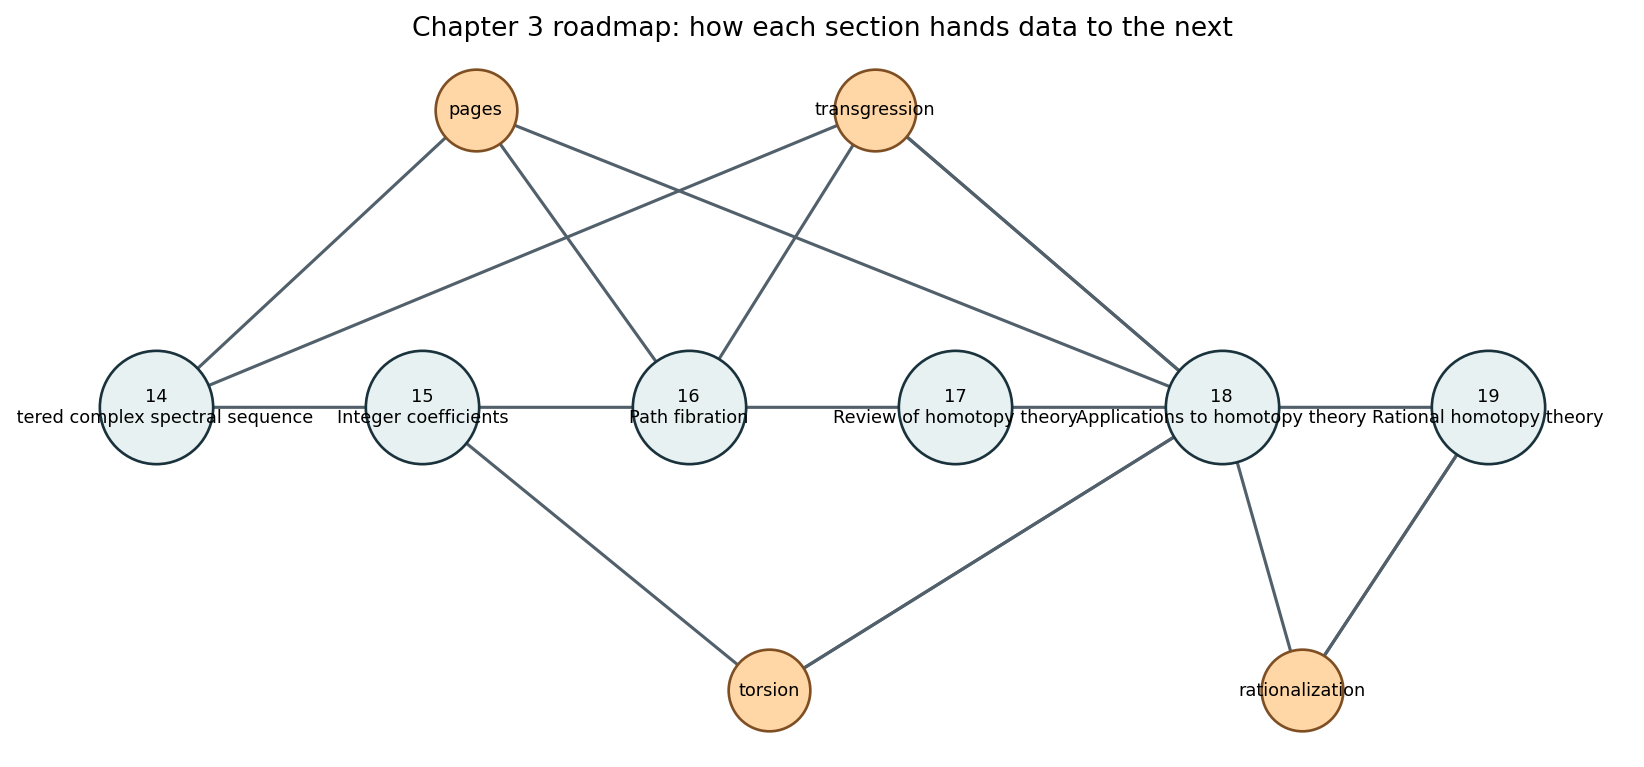

,section,title,source_pages,chapter_role,computational_handle
0,14,Filtered complex spectral sequence,154-181,construct pages and apply them to double compl...,bigraded page grid and total differential check
1,15,Integer coefficients,182-196,replace de Rham forms by singular chains/cocha...,Smith-normal-form torsion model for RP^2
2,16,Path fibration,197-205,use the contractible path space to force trans...,d_n arrow from fiber generator to base generator
3,17,Review of homotopy theory,206-238,"prepare homotopy groups, cell attachments, Hur...",proof dependency graph
4,18,Applications to homotopy theory,239-258,"organize Eilenberg-MacLane spaces, transgressi...",tower dependencies and rational/torsion separa...
5,19,Rational homotopy theory,259-265,translate rational homotopy ranks into generat...,minimal-model generator ladder and finite DGA ...


In [2]:
section_rows = [
    {
        "section": "14",
        "title": "Filtered complex spectral sequence",
        "source_pages": "154-181",
        "chapter_role": "construct pages and apply them to double complexes, fiber bundles, products, and Gysin",
        "computational_handle": "bigraded page grid and total differential check",
    },
    {
        "section": "15",
        "title": "Integer coefficients",
        "source_pages": "182-196",
        "chapter_role": "replace de Rham forms by singular chains/cochains so torsion is visible",
        "computational_handle": "Smith-normal-form torsion model for RP^2",
    },
    {
        "section": "16",
        "title": "Path fibration",
        "source_pages": "197-205",
        "chapter_role": "use the contractible path space to force transgressions in loop-space computations",
        "computational_handle": "d_n arrow from fiber generator to base generator",
    },
    {
        "section": "17",
        "title": "Review of homotopy theory",
        "source_pages": "206-238",
        "chapter_role": "prepare homotopy groups, cell attachments, Hurewicz, and Hopf invariant",
        "computational_handle": "proof dependency graph",
    },
    {
        "section": "18",
        "title": "Applications to homotopy theory",
        "source_pages": "239-258",
        "chapter_role": "organize Eilenberg-MacLane spaces, transgression, Postnikov and Whitehead towers",
        "computational_handle": "tower dependencies and rational/torsion separation",
    },
    {
        "section": "19",
        "title": "Rational homotopy theory",
        "source_pages": "259-265",
        "chapter_role": "translate rational homotopy ranks into generators of Sullivan minimal models",
        "computational_handle": "minimal-model generator ladder and finite DGA cohomology",
    },
]
section_table_path = save_csv(section_rows, TABLES / "chapter-03-section-roadmap.csv")

G = nx.DiGraph()
for row in section_rows:
    label = f"{row['section']}\n{row['title']}"
    G.add_node(label, kind="section", pages=row["source_pages"])
for left, right in zip(section_rows, section_rows[1:]):
    G.add_edge(f"{left['section']}\n{left['title']}", f"{right['section']}\n{right['title']}")
bridge_nodes = {
    "pages": ["14\nFiltered complex spectral sequence", "16\nPath fibration", "18\nApplications to homotopy theory"],
    "torsion": ["15\nInteger coefficients", "18\nApplications to homotopy theory"],
    "transgression": ["14\nFiltered complex spectral sequence", "16\nPath fibration", "18\nApplications to homotopy theory"],
    "rationalization": ["18\nApplications to homotopy theory", "19\nRational homotopy theory"],
}
for bridge, targets in bridge_nodes.items():
    G.add_node(bridge, kind="bridge")
    for target in targets:
        G.add_edge(target, bridge)
        if bridge != "pages":
            G.add_edge(bridge, targets[-1])

pos = {}
for i, row in enumerate(section_rows):
    pos[f"{row['section']}\n{row['title']}"] = (i, 0)
pos.update({"pages": (1.2, 1.0), "torsion": (2.3, -0.95), "transgression": (2.7, 1.0), "rationalization": (4.3, -0.95)})

fig, ax = plt.subplots(figsize=(13, 5.7))
section_nodes = [n for n, d in G.nodes(data=True) if d.get("kind") == "section"]
bridge_nodes_list = [n for n, d in G.nodes(data=True) if d.get("kind") == "bridge"]
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.4, edge_color="#51606a")
nx.draw_networkx_nodes(G, pos, nodelist=section_nodes, node_color="#e8f1f2", edgecolors="#19323c", node_size=2600, linewidths=1.2, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=bridge_nodes_list, node_color="#ffd6a5", edgecolors="#7f4f24", node_size=1350, linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Chapter 3 roadmap: how each section hands data to the next")
ax.axis("off")
roadmap_path = save_matplotlib(fig, FIGURES / "chapter-03-section-roadmap.png")
plt.close(fig)
roadmap_json_path = save_json({"sections": section_rows, "bridges": bridge_nodes, "edge_count": G.number_of_edges()}, CHECKS / "chapter-03-section-roadmap.json")

display_artifact(roadmap_path, width=960)
display(pd.DataFrame(section_rows))


## 1. Filtered Complexes: Pages Are Successive Approximations

A filtration hides information in layers. The associated graded object lets us inspect one layer at a time, and the spectral sequence records what survives after correcting for deeper and deeper layers.

On a cohomological first-quadrant page, the differential `d_r` has bidegree

`d_r: E_r^{p,q} -> E_r^{p+r, q-r+1}`.

So `d_0` is vertical, `d_1` is horizontal, and later differentials are diagonal leaps. That simple slope rule is the first visual anchor for the chapter. The static figure below is deliberately small: it teaches how the same page can be read as a map of possible cancellations. The HTML companion keeps hover labels for the source and target bidegrees.

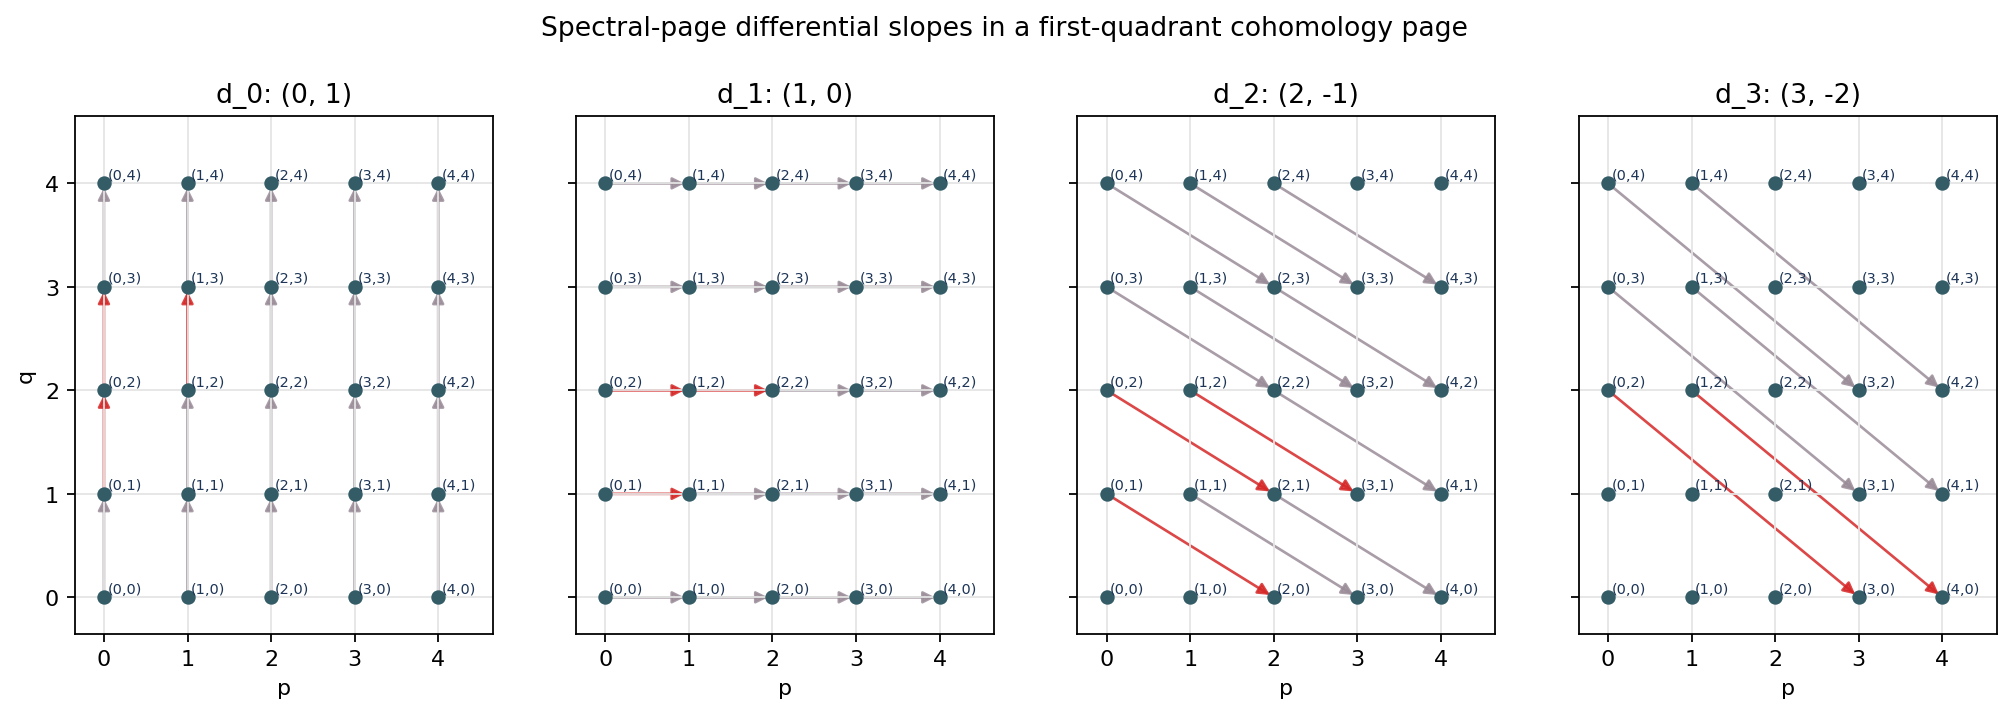

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


,page,r,delta_p,delta_q,visible_arrow_count
0,E_0,0,0,1,20
1,E_1,1,1,0,20
2,E_2,2,2,-1,12
3,E_3,3,3,-2,6


In [3]:
def page_shift(r: int) -> tuple[int, int]:
    return (r, 1 - r)

page_rs = [0, 1, 2, 3]
points = [(p, q) for p in range(5) for q in range(5)]
fig, axes = plt.subplots(1, len(page_rs), figsize=(15.5, 4.2), sharex=True, sharey=True)
shift_rows = []
for ax, r in zip(axes, page_rs):
    dx, dy = page_shift(r)
    for p, q in points:
        ax.scatter(p, q, s=30, color="#335c67", zorder=3)
        ax.text(p + 0.04, q + 0.04, f"({p},{q})", fontsize=6.5, color="#1d3557")
    starts = [(p, q) for p, q in points if (p + dx, q + dy) in points]
    for p, q in starts:
        color = "#d62828" if (p, q) in {(0, 1), (0, 2), (1, 2)} else "#9a8c98"
        arrow = FancyArrowPatch((p, q), (p + dx, q + dy), arrowstyle="-|>", mutation_scale=11, lw=1.2, color=color, alpha=0.85)
        ax.add_patch(arrow)
    shift_rows.append({"page": f"E_{r}", "r": r, "delta_p": dx, "delta_q": dy, "visible_arrow_count": len(starts)})
    ax.set_title(f"d_{r}: ({dx}, {dy})")
    ax.set_xlim(-0.35, 4.65)
    ax.set_ylim(-0.35, 4.65)
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.grid(True, color="#e5e5e5")
    ax.set_xlabel("p")
axes[0].set_ylabel("q")
fig.suptitle("Spectral-page differential slopes in a first-quadrant cohomology page", y=1.03)
spectral_slopes_path = save_matplotlib(fig, FIGURES / "spectral-page-differential-slopes.png")
plt.close(fig)

plotly_fig = make_subplots(rows=1, cols=4, subplot_titles=[f"E_{r}: d_{r}" for r in page_rs], horizontal_spacing=0.05)
for col, r in enumerate(page_rs, start=1):
    dx, dy = page_shift(r)
    plotly_fig.add_trace(
        go.Scatter(
            x=[p for p, q in points],
            y=[q for p, q in points],
            mode="markers+text",
            text=[f"E_{r}^{{{p},{q}}}" for p, q in points],
            textposition="top right",
            marker=dict(size=8, color="#335c67"),
            hovertemplate="bidegree (%{x}, %{y})<extra></extra>",
            showlegend=False,
        ),
        row=1,
        col=col,
    )
    for p, q in points:
        target = (p + dx, q + dy)
        if target in points:
            plotly_fig.add_trace(
                go.Scatter(
                    x=[p, target[0]],
                    y=[q, target[1]],
                    mode="lines",
                    line=dict(width=2, color="#d62828" if (p, q) == (0, max(1, r)) else "#7d8597"),
                    hovertemplate=f"d_{r}: ({p},{q}) -> ({target[0]},{target[1]})<extra></extra>",
                    showlegend=False,
                ),
                row=1,
                col=col,
            )
plotly_fig.update_xaxes(range=[-0.4, 4.6], dtick=1, title_text="p")
plotly_fig.update_yaxes(range=[-0.4, 4.6], dtick=1, title_text="q")
plotly_fig.update_layout(title="Interactive spectral-page slope board", height=430, width=1120, margin=dict(l=40, r=20, t=70, b=30))
spectral_html_path = save_plotly_html(plotly_fig, HTML / "spectral-page-differential-slopes.html")
spectral_shift_path = save_json({"degree_rule": "d_r has bidegree (r, 1-r)", "rows": shift_rows}, CHECKS / "spectral-page-degree-shifts.json")

display_artifact(spectral_slopes_path, width=980)
display_artifact(spectral_html_path, width=980, height=470)
display(pd.DataFrame(shift_rows))


A common learner error is to treat the page index as only a label. The picture shows why that loses information. Increasing `r` changes the slope and therefore changes which bidegrees can communicate. This is exactly what makes transgression visible later: a class can survive the short differentials and then be hit by a longer one.

## 2. A Signed Double Complex: The Total Differential Has to Square to Zero

Section 14 repeatedly uses double complexes. The sign is not cosmetic. If the horizontal and vertical maps commute instead of anticommute after the total-degree sign is inserted, the total differential can fail.

The toy double complex below has four generators. Its vertical map sends the bottom row upward, and its signed horizontal map sends the left column to the right column with a sign on the top edge. The check is exact over the integers: `D = d_vertical + d_horizontal` and `D^2 = 0`.

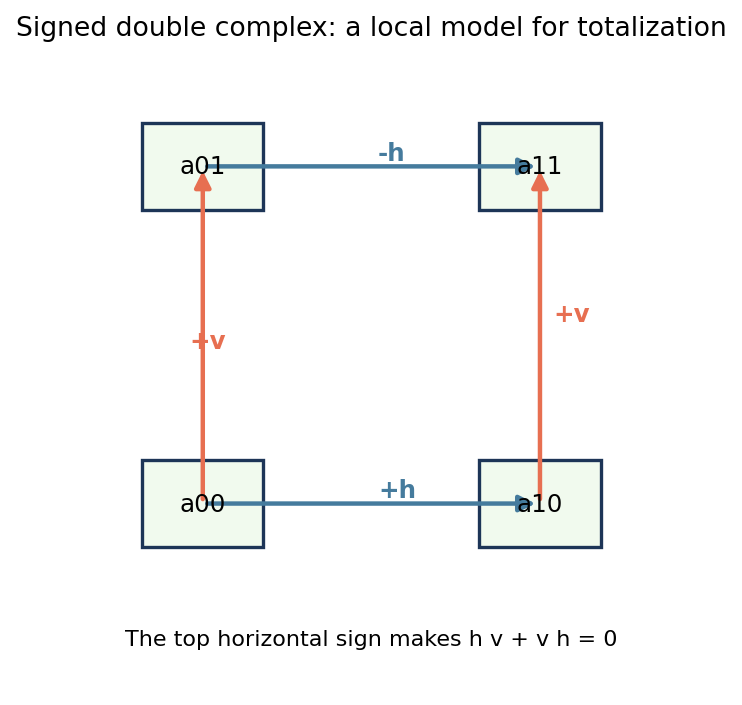

{
  "basis": [
    "a00",
    "a10",
    "a01",
    "a11"
  ],
  "horizontal_matrix": [
    [
      0,
      0,
      0,
      0
    ],
    [
      1,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      -1,
      0
    ]
  ],
  "vertical_matrix": [
    [
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0
    ],
    [
      1,
      0,
      0,
      0
    ],
    [
      0,
      1,
      0,
      0
    ]
  ],
  "total_matrix": [
    [
      0,
      0,
      0,
      0
    ],
    [
      1,
      0,
      0,
      0
    ],
    [
      1,
      0,
      0,
      0
    ],
    [
      0,
      1,
      -1,
      0
    ]
  ],
  "horizontal_squared_zero": true,
  "vertical_squared_zero": true,
  "anticommutator_zero": true,
  "total_squared_zero": true
}


In [4]:
basis = ["a00", "a10", "a01", "a11"]
coords = {"a00": (0, 0), "a10": (1, 0), "a01": (0, 1), "a11": (1, 1)}
idx = {name: i for i, name in enumerate(basis)}
H = sp.zeros(4)  # signed horizontal part
V = sp.zeros(4)  # vertical part
H[idx["a10"], idx["a00"]] = 1
H[idx["a11"], idx["a01"]] = -1
V[idx["a01"], idx["a00"]] = 1
V[idx["a11"], idx["a10"]] = 1
D = H + V
anticommutator = H * V + V * H
checks_double = {
    "basis": basis,
    "horizontal_matrix": [[int(H[i, j]) for j in range(4)] for i in range(4)],
    "vertical_matrix": [[int(V[i, j]) for j in range(4)] for i in range(4)],
    "total_matrix": [[int(D[i, j]) for j in range(4)] for i in range(4)],
    "horizontal_squared_zero": H * H == sp.zeros(4),
    "vertical_squared_zero": V * V == sp.zeros(4),
    "anticommutator_zero": anticommutator == sp.zeros(4),
    "total_squared_zero": D * D == sp.zeros(4),
}

def draw_double_complex():
    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    for name, (x, y) in coords.items():
        ax.add_patch(Rectangle((x - 0.18, y - 0.13), 0.36, 0.26, facecolor="#f1faee", edgecolor="#1d3557", lw=1.5))
        ax.text(x, y, name, ha="center", va="center", fontsize=11)
    arrows = [
        ("a00", "a10", "+h", "#457b9d", 0.02),
        ("a01", "a11", "-h", "#457b9d", 0.02),
        ("a00", "a01", "+v", "#e76f51", -0.04),
        ("a10", "a11", "+v", "#e76f51", 0.04),
    ]
    for s, t, label, color, offset in arrows:
        x0, y0 = coords[s]
        x1, y1 = coords[t]
        arrow = FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>", mutation_scale=15, lw=2, color=color)
        ax.add_patch(arrow)
        ax.text((x0 + x1) / 2 + offset, (y0 + y1) / 2 + offset, label, color=color, fontsize=11, weight="bold")
    ax.text(0.5, -0.42, "The top horizontal sign makes h v + v h = 0", ha="center", fontsize=10)
    ax.set_xlim(-0.45, 1.45)
    ax.set_ylim(-0.55, 1.35)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title("Signed double complex: a local model for totalization")
    return fig

fig = draw_double_complex()
double_complex_path = save_matplotlib(fig, FIGURES / "double-complex-total-differential.png")
plt.close(fig)
double_complex_json_path = save_json(checks_double, CHECKS / "double-complex-total-differential.json")

display_artifact(double_complex_path, width=700)
print(json.dumps(checks_double, indent=2))


## 3. Integer Coefficients: Torsion Is a Page Feature, Not a Form Feature

Section 15 changes coefficient systems because differential forms over the reals cannot see finite torsion. A tiny cellular model makes the issue concrete.

For `RP^2`, use one cell in dimensions 0, 1, and 2. The only nonzero cellular boundary is multiplication by 2 from the 2-cell to the 1-cell. Over `Z`, the cokernel contains `Z/2`. Over `Q` or `R`, multiplication by 2 is invertible, so the same finite torsion disappears.

This is the computational reason the chapter moves from de Rham forms to singular chains/cochains with integer coefficients before using spectral sequences in homotopy theory.

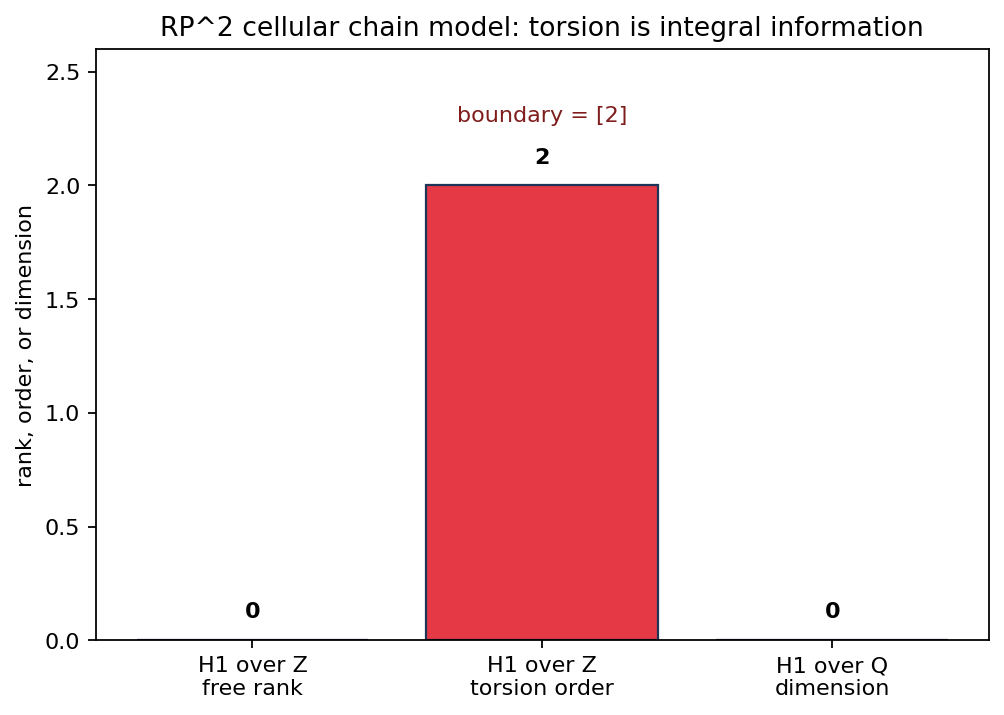

,coefficient_system,H0_rank,H1_free_rank,H1_torsion,H2_rank
0,Z,1,0,Z/2,0
1,Q or R,1,0,none,0


In [5]:
d2_rp2 = sp.Matrix([[2]])
d1_rp2 = sp.Matrix([[0]])
rank_d2_Z = d2_rp2.rank()
rank_d1_Z = d1_rp2.rank()
rp2_rows = [
    {"coefficient_system": "Z", "H0_rank": 1, "H1_free_rank": 0, "H1_torsion": "Z/2", "H2_rank": 0},
    {"coefficient_system": "Q or R", "H0_rank": 1, "H1_free_rank": 0, "H1_torsion": "none", "H2_rank": 0},
]
rp2_checks = {
    "cellular_boundary_d2": [[2]],
    "cellular_boundary_d1": [[0]],
    "boundary_squared_zero": d1_rp2 * d2_rp2 == sp.zeros(1, 1),
    "smith_invariant_factor_d2": 2,
    "H1_integral_torsion_order": 2,
    "H1_rational_dimension": 0,
    "lesson": "The real de Rham theory sees the rational rank, not the finite Z/2 class.",
}
rp2_table_path = save_csv(rp2_rows, TABLES / "integer-coefficients-rp2-torsion.csv")
rp2_json_path = save_json(rp2_checks, CHECKS / "integer-coefficients-rp2-torsion.json")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
labels = ["H1 over Z\nfree rank", "H1 over Z\ntorsion order", "H1 over Q\ndimension"]
values = [0, 2, 0]
colors = ["#a8dadc", "#e63946", "#a8dadc"]
ax.bar(labels, values, color=colors, edgecolor="#1d3557")
ax.set_ylim(0, 2.6)
ax.set_ylabel("rank, order, or dimension")
ax.set_title("RP^2 cellular chain model: torsion is integral information")
for i, value in enumerate(values):
    ax.text(i, value + 0.08, str(value), ha="center", va="bottom", weight="bold")
ax.text(1, 2.28, "boundary = [2]", ha="center", color="#7f1d1d")
rp2_fig_path = save_matplotlib(fig, FIGURES / "integer-coefficients-rp2-torsion.png")
plt.close(fig)

display_artifact(rp2_fig_path, width=760)
display(pd.DataFrame(rp2_rows))


## 4. Path Fibration: Contractibility Forces a Transgression

For a based space `X`, the path fibration has fiber `Omega X`, total space `P X`, and base `X`. The key special feature is that `P X` is contractible. On a spectral page, this means positive-degree classes cannot simply survive forever. Something has to hit them or be hit by them.

For a sphere, the cartoon is especially clean. A generator in the loop-space direction and a generator in the base direction are connected by a differential of length `n`:

`d_n: E_n^{0,n-1} -> E_n^{n,0}`.

The model below does not compute the full loop-space ring. It isolates the transgression mechanism that the chapter uses repeatedly: a class that survives early pages can become the exact bridge between fiber and base.

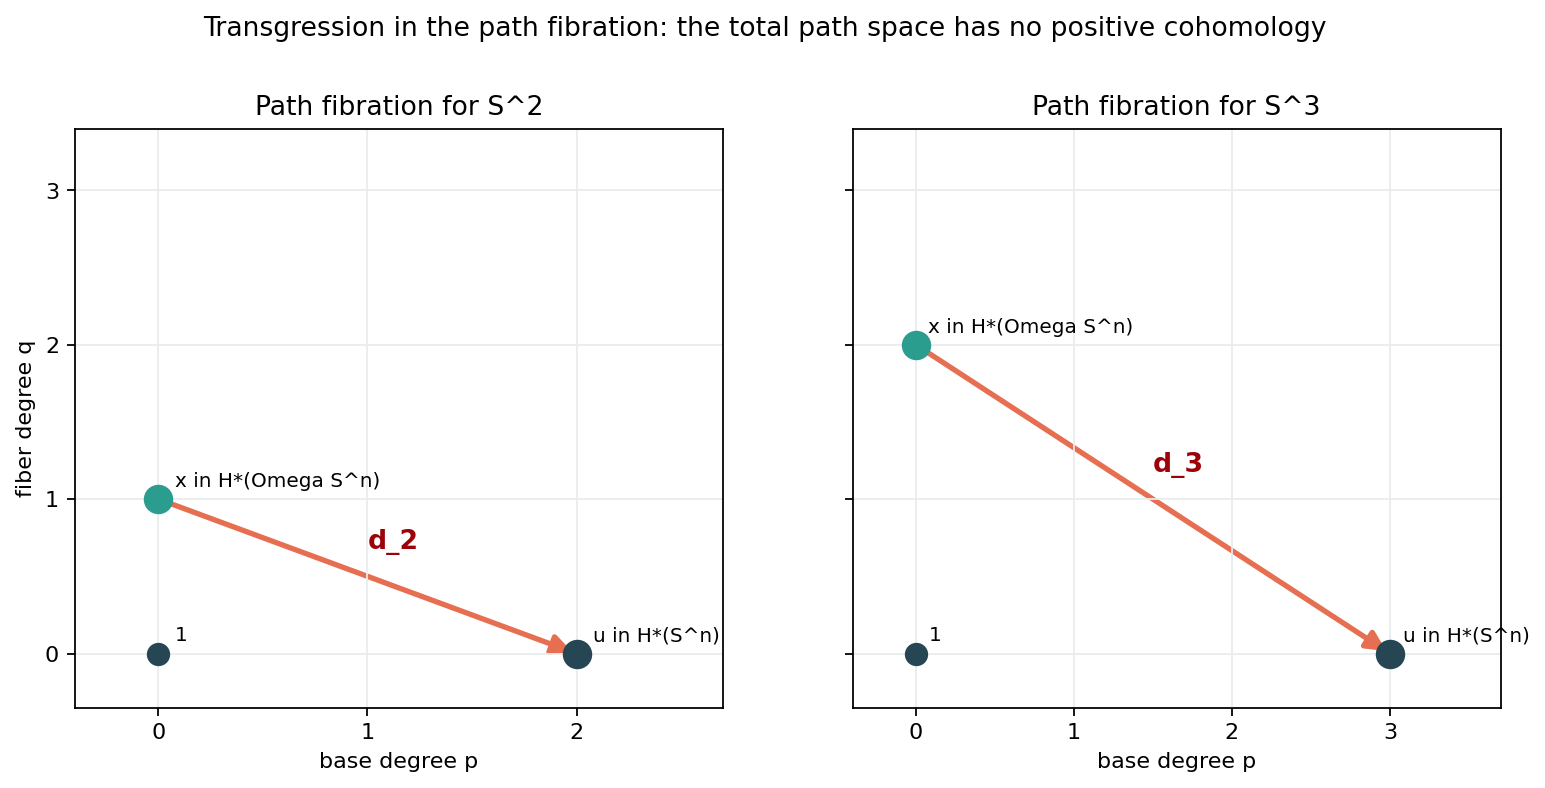

,sphere,fiber_generator_bidegree,base_generator_bidegree,differential,matrix,rank,positive_degree_pair_killed
0,S^2,"[0, 1]","[2, 0]",d_2,[[1]],1,True
1,S^3,"[0, 2]","[3, 0]",d_3,[[1]],1,True


In [6]:
def path_fibration_case(n: int) -> dict:
    matrix = sp.Matrix([[1]])
    return {
        "sphere": f"S^{n}",
        "fiber_generator_bidegree": [0, n - 1],
        "base_generator_bidegree": [n, 0],
        "differential": f"d_{n}",
        "matrix": [[1]],
        "rank": int(matrix.rank()),
        "positive_degree_pair_killed": matrix.rank() == 1,
    }

path_cases = [path_fibration_case(2), path_fibration_case(3)]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.7), sharey=True)
for ax, case in zip(axes, path_cases):
    n = int(case["sphere"].split("^")[1])
    points_case = {"x in H*(Omega S^n)": tuple(case["fiber_generator_bidegree"]), "u in H*(S^n)": tuple(case["base_generator_bidegree"]), "1": (0, 0)}
    for label, (p, q) in points_case.items():
        ax.scatter(p, q, s=150 if label != "1" else 90, color="#2a9d8f" if label.startswith("x") else "#264653", zorder=3)
        ax.text(p + 0.08, q + 0.08, label, fontsize=9)
    start = tuple(case["fiber_generator_bidegree"])
    end = tuple(case["base_generator_bidegree"])
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=18, lw=2.4, color="#e76f51"))
    ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2 + 0.18, case["differential"], color="#9d0208", fontsize=12, weight="bold")
    ax.set_xlim(-0.4, n + 0.7)
    ax.set_ylim(-0.35, max(3, n) + 0.4)
    ax.set_xticks(range(n + 1))
    ax.set_yticks(range(max(3, n) + 1))
    ax.grid(True, color="#e9ecef")
    ax.set_xlabel("base degree p")
    ax.set_title(f"Path fibration for {case['sphere']}")
axes[0].set_ylabel("fiber degree q")
fig.suptitle("Transgression in the path fibration: the total path space has no positive cohomology", y=1.03)
path_fibration_fig_path = save_matplotlib(fig, FIGURES / "path-fibration-transgression.png")
plt.close(fig)
path_fibration_json_path = save_json({"cases": path_cases, "contractible_total_space_check": all(c["positive_degree_pair_killed"] for c in path_cases)}, CHECKS / "path-fibration-transgression.json")

display_artifact(path_fibration_fig_path, width=880)
display(pd.DataFrame(path_cases))


## 5. Gysin Sequence: The Euler Class as a Spectral Differential

For an oriented sphere bundle, most rows on the fiber page vanish. In the circle-bundle case over `S^2`, only two fiber rows remain. The long exact Gysin sequence is the surviving one-dimensional shadow of the spectral sequence.

The differential `d_2` from the fiber class to the top base class is multiplication by the Euler class. In a circle bundle over `S^2`, that class is an integer `e`. The table below sweeps `e = 0, 1, 2`:

- `e = 0` is the product-like case, so the differential vanishes.
- `e = 1` is the Hopf-fibration pattern, so the middle cohomology is killed.
- `e = 2` leaves finite torsion in `H^2`.

This makes the book's abstract phrase "multiplication by the Euler class" into a visible integer matrix.

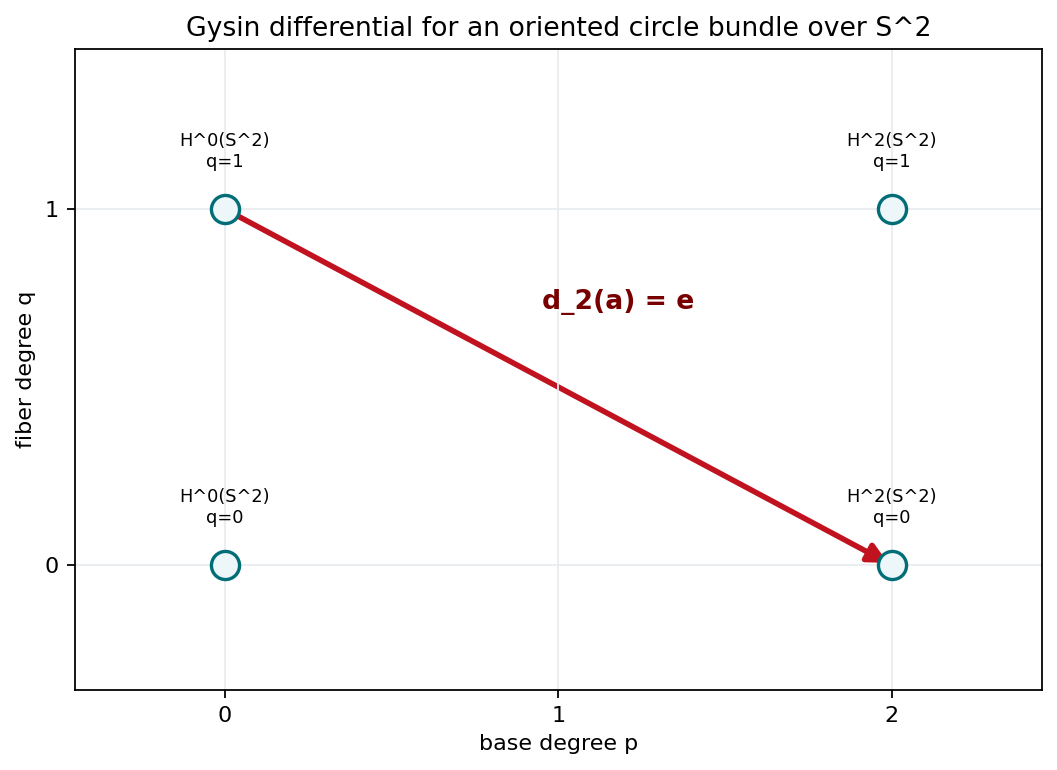

,euler_number,d2_matrix,d2_rank_over_Q,H1_total,H2_total,torsion_order_recorded_as_0_for_free_Z
0,0,[[0]],0,Z,Z,0
1,1,[[1]],1,0,0,1
2,2,[[2]],1,0,Z/2,2


In [7]:
def circle_bundle_over_s2_summary(e: int) -> dict:
    if e == 0:
        h1 = "Z"
        h2 = "Z"
        torsion_order = 0
        rank = 0
    else:
        h1 = "0"
        h2 = "0" if abs(e) == 1 else f"Z/{abs(e)}"
        torsion_order = 1 if abs(e) == 1 else abs(e)
        rank = 1
    return {
        "euler_number": e,
        "d2_matrix": [[e]],
        "d2_rank_over_Q": rank,
        "H1_total": h1,
        "H2_total": h2,
        "torsion_order_recorded_as_0_for_free_Z": torsion_order,
    }

gysin_rows = [circle_bundle_over_s2_summary(e) for e in [0, 1, 2]]
gysin_table_path = save_csv(gysin_rows, TABLES / "gysin-euler-differential.csv")
gysin_json_path = save_json({"model": "oriented S^1 bundle over S^2", "rows": gysin_rows, "e_equals_1_kills_middle_cohomology": gysin_rows[1]["H1_total"] == "0" and gysin_rows[1]["H2_total"] == "0"}, CHECKS / "gysin-euler-differential.json")

fig, ax = plt.subplots(figsize=(7.8, 5.2))
for p in [0, 2]:
    for q in [0, 1]:
        ax.scatter(p, q, s=160, color="#edf6f9", edgecolor="#006d77", linewidth=1.5, zorder=3)
        ax.text(p, q + 0.12, f"H^{p}(S^2)\nq={q}", ha="center", fontsize=8)
ax.add_patch(FancyArrowPatch((0, 1), (2, 0), arrowstyle="-|>", mutation_scale=18, lw=2.5, color="#c1121f"))
ax.text(0.95, 0.72, "d_2(a) = e", color="#780000", fontsize=12, weight="bold")
ax.set_xlim(-0.45, 2.45)
ax.set_ylim(-0.35, 1.45)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1])
ax.grid(True, color="#e9ecef")
ax.set_xlabel("base degree p")
ax.set_ylabel("fiber degree q")
ax.set_title("Gysin differential for an oriented circle bundle over S^2")
gysin_fig_path = save_matplotlib(fig, FIGURES / "gysin-euler-differential.png")
plt.close(fig)

display_artifact(gysin_fig_path, width=760)
display(pd.DataFrame(gysin_rows))


## 6. Homotopy Theory Review and Applications: A Proof Map

Sections 17 and 18 contain many named constructions. The point of the review is not to memorize names. The point is to make spectral sequences usable in homotopy theory.

Read the graph below from left to right. The path fibration supplies a spectral sequence. Hurewicz turns first nontrivial homotopy into homology in the right range. Eilenberg-MacLane spaces isolate a single homotopy group. Postnikov towers assemble spaces from those isolates; Whitehead towers kill lower groups instead. The Serre theorem uses those towers plus rational cohomology input to separate torsion from free rational information. Sullivan minimal models then compress the rational part into a differential graded algebra.

The graph is an invariant scaffold: if one removes the Hurewicz bridge, the later homotopy calculations lose their first nontrivial homology input; if one removes integer coefficients, torsion cannot be tracked.

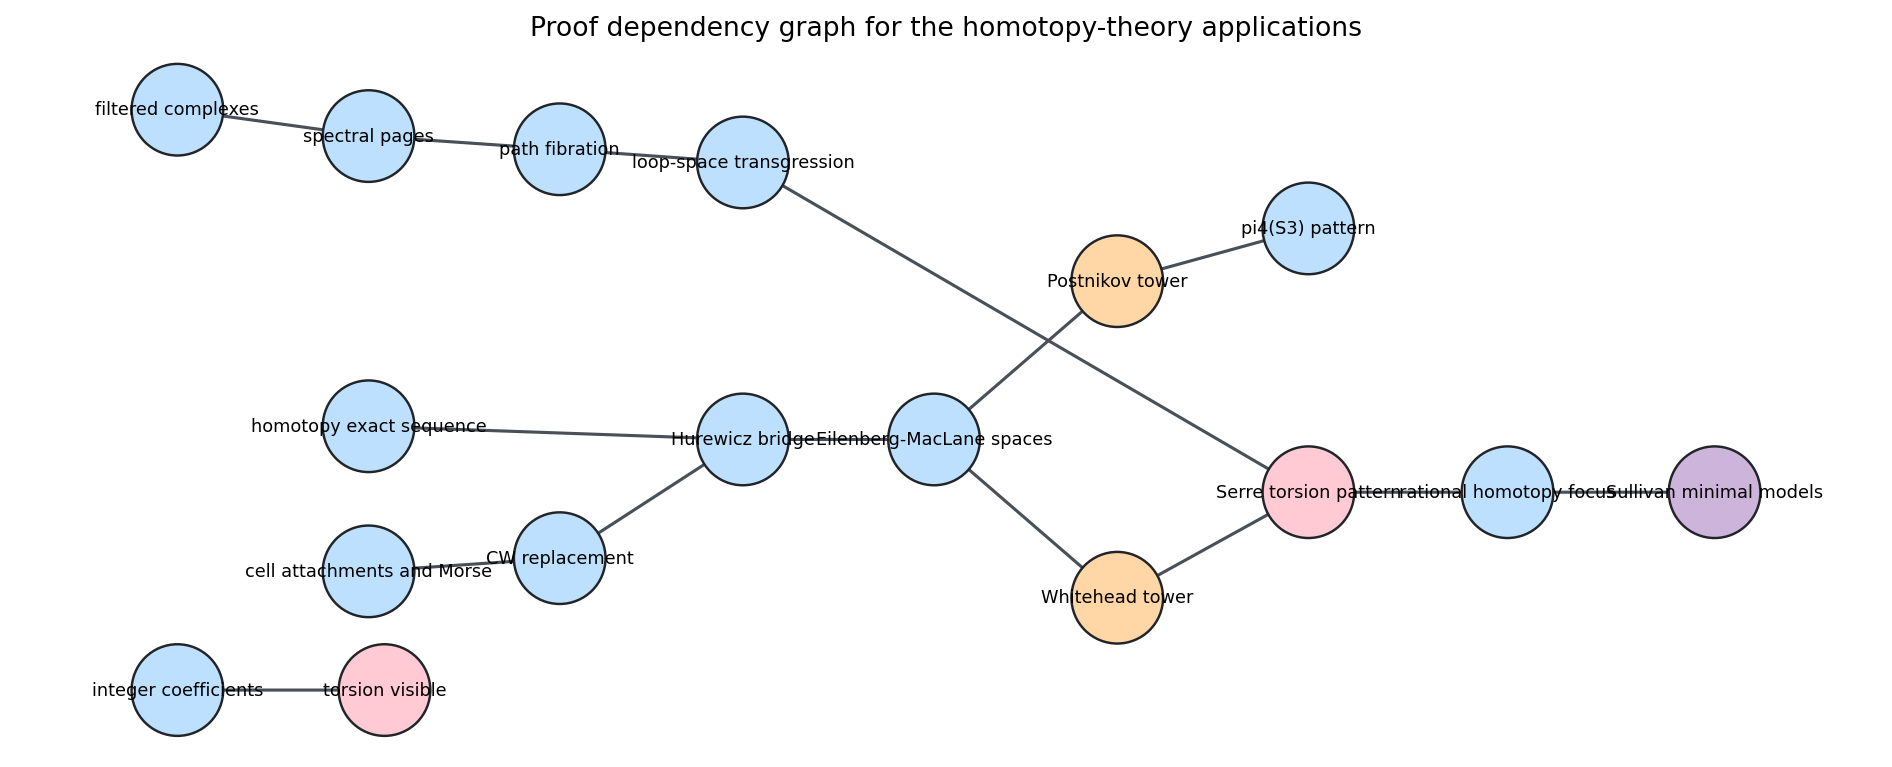

DAG check: True with 17 nodes and 15 edges


In [8]:
proof_edges = [
    ("filtered complexes", "spectral pages"),
    ("integer coefficients", "torsion visible"),
    ("spectral pages", "path fibration"),
    ("path fibration", "loop-space transgression"),
    ("homotopy exact sequence", "Hurewicz bridge"),
    ("cell attachments and Morse", "CW replacement"),
    ("CW replacement", "Hurewicz bridge"),
    ("Hurewicz bridge", "Eilenberg-MacLane spaces"),
    ("Eilenberg-MacLane spaces", "Postnikov tower"),
    ("Eilenberg-MacLane spaces", "Whitehead tower"),
    ("Postnikov tower", "pi4(S3) pattern"),
    ("Whitehead tower", "Serre torsion pattern"),
    ("loop-space transgression", "Serre torsion pattern"),
    ("Serre torsion pattern", "rational homotopy focus"),
    ("rational homotopy focus", "Sullivan minimal models"),
]
PG = nx.DiGraph()
PG.add_edges_from(proof_edges)
proof_pos = {
    "filtered complexes": (0, 1.2),
    "integer coefficients": (0, -1.0),
    "spectral pages": (1.2, 1.1),
    "torsion visible": (1.3, -1.0),
    "path fibration": (2.4, 1.05),
    "loop-space transgression": (3.55, 1.0),
    "homotopy exact sequence": (1.2, 0.0),
    "cell attachments and Morse": (1.2, -0.55),
    "CW replacement": (2.4, -0.5),
    "Hurewicz bridge": (3.55, -0.05),
    "Eilenberg-MacLane spaces": (4.75, -0.05),
    "Postnikov tower": (5.9, 0.55),
    "Whitehead tower": (5.9, -0.65),
    "pi4(S3) pattern": (7.1, 0.75),
    "Serre torsion pattern": (7.1, -0.25),
    "rational homotopy focus": (8.35, -0.25),
    "Sullivan minimal models": (9.65, -0.25),
}
fig, ax = plt.subplots(figsize=(15, 5.7))
node_colors = []
for node in PG.nodes:
    if "tower" in node:
        node_colors.append("#ffd6a5")
    elif node in {"torsion visible", "Serre torsion pattern"}:
        node_colors.append("#ffcad4")
    elif node == "Sullivan minimal models":
        node_colors.append("#cdb4db")
    else:
        node_colors.append("#bde0fe")
nx.draw_networkx_edges(PG, proof_pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.4, edge_color="#495057")
nx.draw_networkx_nodes(PG, proof_pos, ax=ax, node_color=node_colors, edgecolors="#212529", linewidths=1.1, node_size=1700)
nx.draw_networkx_labels(PG, proof_pos, ax=ax, font_size=8)
ax.set_title("Proof dependency graph for the homotopy-theory applications")
ax.axis("off")
proof_graph_path = save_matplotlib(fig, FIGURES / "homotopy-application-proof-graph.png")
plt.close(fig)
proof_graph_json_path = save_json({"nodes": list(PG.nodes()), "edges": proof_edges, "is_dag": nx.is_directed_acyclic_graph(PG)}, CHECKS / "homotopy-application-proof-graph.json")

display_artifact(proof_graph_path, width=980)
print(f"DAG check: {nx.is_directed_acyclic_graph(PG)} with {PG.number_of_nodes()} nodes and {PG.number_of_edges()} edges")


## 7. Rational Homotopy: Minimal Models Count Rational Generators

Section 19 changes the language again. Instead of keeping torsion, rational homotopy deliberately discards it. Sullivan's minimal model keeps the rational part in a free differential graded commutative algebra.

For this notebook, a minimal model is treated as a generator ledger with a differential:

- Odd sphere: one odd-degree generator with zero differential.
- Even sphere: one even-degree generator `x` and one odd-degree generator `y`, with `d y = x^2`.
- Complex projective space: one degree-2 generator and one higher odd generator, with the differential killing the first forbidden power.
- Wedge `S^2 vee S^2`: several generators appear in low degrees because products must be killed and higher relations then appear.

The finite check below computes the cohomology of the model for `S^2` up to degree 10. The result should be one class in degree 0, one in degree 2, and no other classes in the checked range. That is exactly the rational cohomology pattern of `S^2`.

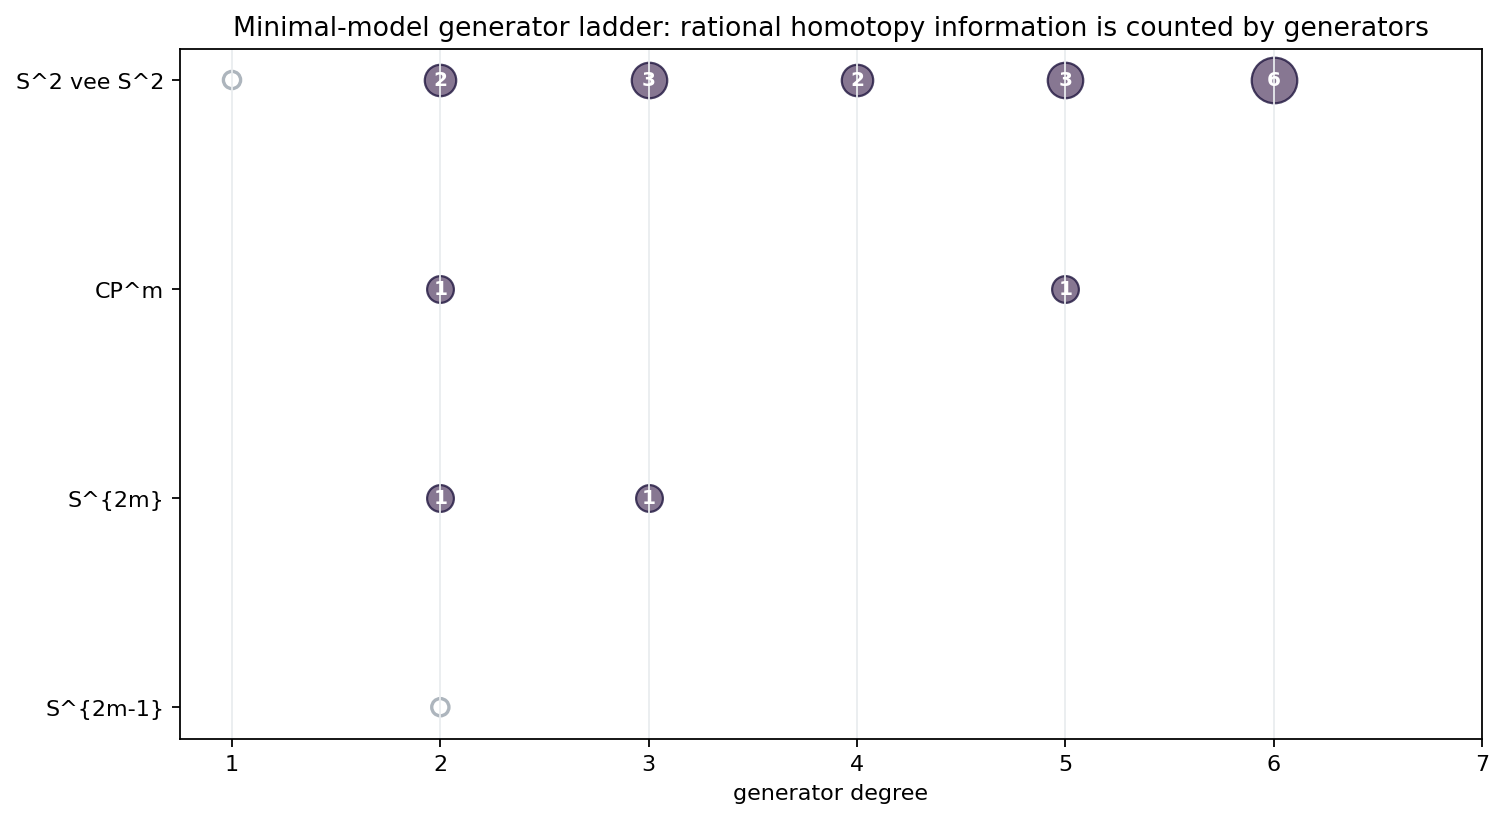

,degree,basis_dim,kernel_dim,image_dim_from_previous_degree,cohomology_dim
0,0,1,1,0,1
1,1,0,0,0,0
2,2,1,1,0,1
3,3,1,0,0,0
4,4,1,1,1,0
5,5,1,0,0,0
6,6,1,1,1,0
7,7,1,0,0,0
8,8,1,1,1,0
9,9,1,0,0,0


In [9]:
model_rows = [
    {"space": "S^{2m-1}", "degree": 2, "generator_count_for_display": 0, "note": "template uses one generator in odd degree 2m-1"},
    {"space": "S^{2m}", "degree": 2, "generator_count_for_display": 1, "note": "x in degree 2m"},
    {"space": "S^{2m}", "degree": 3, "generator_count_for_display": 1, "note": "for S^2, y in degree 3 with dy=x^2"},
    {"space": "CP^m", "degree": 2, "generator_count_for_display": 1, "note": "x in degree 2"},
    {"space": "CP^m", "degree": 5, "generator_count_for_display": 1, "note": "example display for CP^2: y in degree 5 with dy=x^3"},
]
wedge_counts = {1: 0, 2: 2, 3: 3, 4: 2, 5: 3, 6: 6}
for degree, count in wedge_counts.items():
    model_rows.append({"space": "S^2 vee S^2", "degree": degree, "generator_count_for_display": count, "note": "low-degree Sullivan-model count"})
minimal_model_table_path = save_csv(model_rows, TABLES / "minimal-model-generator-ladder.csv")

fig, ax = plt.subplots(figsize=(10.5, 5.6))
spaces = ["S^{2m-1}", "S^{2m}", "CP^m", "S^2 vee S^2"]
y_pos = {space: i for i, space in enumerate(spaces)}
for row in model_rows:
    count = row["generator_count_for_display"]
    if count == 0:
        ax.scatter(row["degree"], y_pos[row["space"]], s=60, facecolors="none", edgecolors="#adb5bd", linewidth=1.5)
    else:
        ax.scatter(row["degree"], y_pos[row["space"]], s=90 + 55 * count, color="#6d597a", alpha=0.82, edgecolor="#231942")
        ax.text(row["degree"], y_pos[row["space"]], str(count), ha="center", va="center", color="white", fontsize=9, weight="bold")
ax.set_yticks(list(y_pos.values()), list(y_pos.keys()))
ax.set_xticks(range(1, 8))
ax.set_xlabel("generator degree")
ax.set_title("Minimal-model generator ladder: rational homotopy information is counted by generators")
ax.grid(True, axis="x", color="#e9ecef")
minimal_model_fig_path = save_matplotlib(fig, FIGURES / "minimal-model-generator-ladder.png")
plt.close(fig)

def s2_minimal_model_bases(max_degree: int = 10):
    bases = {k: [] for k in range(max_degree + 2)}
    for a in range(0, max_degree // 2 + 4):
        deg_xa = 2 * a
        if deg_xa <= max_degree + 1:
            bases[deg_xa].append((a, 0))
        deg_xay = 2 * a + 3
        if deg_xay <= max_degree + 1:
            bases[deg_xay].append((a, 1))
    return bases

def differential_matrix_s2_model(k: int, bases: dict[int, list[tuple[int, int]]]) -> sp.Matrix:
    source = bases.get(k, [])
    target = bases.get(k + 1, [])
    target_index = {monomial: i for i, monomial in enumerate(target)}
    M = sp.zeros(len(target), len(source))
    for j, (a, b) in enumerate(source):
        if b == 1:
            image = (a + 2, 0)
            if image in target_index:
                M[target_index[image], j] = 1
    return M

bases_s2 = s2_minimal_model_bases(10)
cohomology_rows = []
for k in range(0, 11):
    d_k = differential_matrix_s2_model(k, bases_s2)
    d_prev = differential_matrix_s2_model(k - 1, bases_s2) if k > 0 else sp.zeros(len(bases_s2[k]), 0)
    basis_dim = len(bases_s2[k])
    kernel_dim = basis_dim - d_k.rank()
    image_dim = d_prev.rank()
    cohomology_rows.append({
        "degree": k,
        "basis_dim": int(basis_dim),
        "kernel_dim": int(kernel_dim),
        "image_dim_from_previous_degree": int(image_dim),
        "cohomology_dim": int(kernel_dim - image_dim),
    })
s2_cohomology_table_path = save_csv(cohomology_rows, TABLES / "minimal-model-s2-cohomology.csv")
minimal_model_json_path = save_json({
    "model": "S^2 minimal model with deg(x)=2, deg(y)=3, dx=0, dy=x^2",
    "cohomology_rows": cohomology_rows,
    "expected_nonzero_degrees_up_to_10": [0, 2],
    "wedge_s2_vee_s2_generator_counts_1_to_6": wedge_counts,
}, CHECKS / "minimal-model-generator-ladder.json")

display_artifact(minimal_model_fig_path, width=860)
display(pd.DataFrame(cohomology_rows))


## Applied Lab: Sweep the Euler Differential

The lab changes one input: the Euler number `e` in the circle-bundle model over `S^2`. Everything else stays fixed. This is a controlled experiment in the spirit of the chapter: one page differential changes, and the resulting survivor/torsion data changes with it.

Interpretation guide:

- The arrow is zero at `e = 0`, so free classes survive.
- The arrow is an isomorphism over `Z` at `e = 1`, so the middle cohomology disappears.
- For `|e| > 1`, the rational rank still vanishes but finite torsion remains.

That is precisely why the coefficient system matters before the chapter enters homotopy theory.

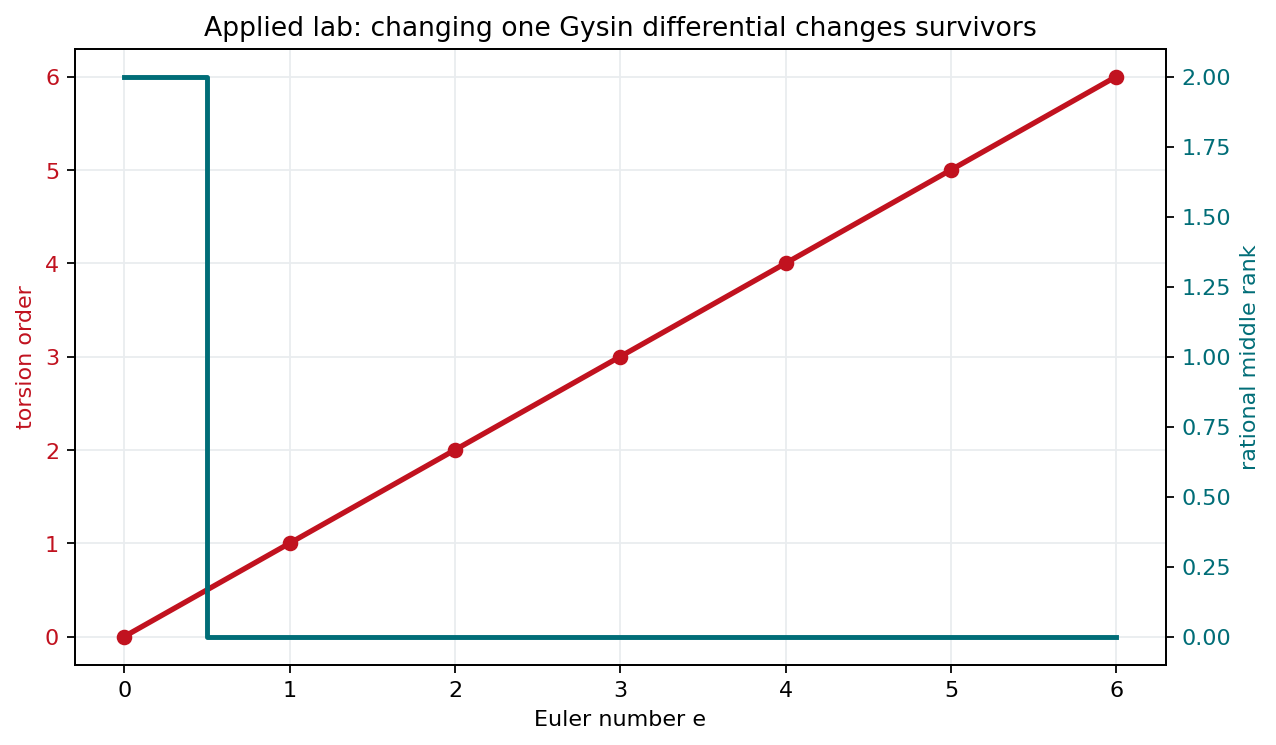

,euler_number,d2_matrix,d2_rank_over_Q,H1_total,H2_total,torsion_order_recorded_as_0_for_free_Z,torsion_order_for_plot,rational_middle_rank_H1_plus_H2
0,0,[[0]],0,Z,Z,0,0,2
1,1,[[1]],1,0,0,1,1,0
2,2,[[2]],1,0,Z/2,2,2,0
3,3,[[3]],1,0,Z/3,3,3,0
4,4,[[4]],1,0,Z/4,4,4,0
5,5,[[5]],1,0,Z/5,5,5,0
6,6,[[6]],1,0,Z/6,6,6,0


In [10]:
lab_rows = [circle_bundle_over_s2_summary(e) for e in range(0, 7)]
for row in lab_rows:
    e = row["euler_number"]
    row["torsion_order_for_plot"] = 0 if e == 0 else abs(e)
    row["rational_middle_rank_H1_plus_H2"] = 2 if e == 0 else 0
lab_table_path = save_csv(lab_rows, TABLES / "applied-lab-euler-number-sweep.csv")
lab_json_path = save_json({"experiment": "sweep e in d2=[e] for oriented S^1 bundles over S^2", "rows": lab_rows}, CHECKS / "applied-lab-euler-number-sweep.json")

fig, ax1 = plt.subplots(figsize=(8.8, 5.0))
e_values = [row["euler_number"] for row in lab_rows]
torsion_orders = [row["torsion_order_for_plot"] for row in lab_rows]
rational_ranks = [row["rational_middle_rank_H1_plus_H2"] for row in lab_rows]
ax1.plot(e_values, torsion_orders, marker="o", color="#c1121f", lw=2.4, label="torsion order in H^2 when finite")
ax1.set_xlabel("Euler number e")
ax1.set_ylabel("torsion order", color="#c1121f")
ax1.tick_params(axis="y", labelcolor="#c1121f")
ax1.set_xticks(e_values)
ax2 = ax1.twinx()
ax2.step(e_values, rational_ranks, where="mid", color="#006d77", lw=2.2, label="rational middle rank")
ax2.set_ylabel("rational middle rank", color="#006d77")
ax2.tick_params(axis="y", labelcolor="#006d77")
ax1.set_title("Applied lab: changing one Gysin differential changes survivors")
ax1.grid(True, color="#e9ecef")
lab_fig_path = save_matplotlib(fig, FIGURES / "applied-lab-euler-number-sweep.png")
plt.close(fig)

display_artifact(lab_fig_path, width=820)
display(pd.DataFrame(lab_rows))


## Final Sanity Checks

The final cell checks three layers.

1. **Artifact integrity.** Every displayed artifact exists and has nonzero size; PNGs are also checked for nonblank pixel variation.
2. **Algebraic identities.** The double-complex total differential squares to zero, the path-fibration transgression matrices have the expected rank, and the Gysin `e = 1` case kills the middle cohomology.
3. **Chapter-specific validations.** Integer torsion appears over `Z` but not over `Q`, and the minimal model for `S^2` has cohomology only in degrees 0 and 2 in the checked range.

In [11]:
# final_sanity
artifact_paths = [
    section_table_path,
    roadmap_path,
    roadmap_json_path,
    spectral_slopes_path,
    spectral_html_path,
    spectral_shift_path,
    double_complex_path,
    double_complex_json_path,
    rp2_table_path,
    rp2_json_path,
    rp2_fig_path,
    path_fibration_fig_path,
    path_fibration_json_path,
    gysin_table_path,
    gysin_json_path,
    gysin_fig_path,
    proof_graph_path,
    proof_graph_json_path,
    minimal_model_table_path,
    minimal_model_fig_path,
    s2_cohomology_table_path,
    minimal_model_json_path,
    lab_table_path,
    lab_json_path,
    lab_fig_path,
]
assert_artifacts(artifact_paths, min_bytes=80)

png_paths = [p for p in artifact_paths if Path(p).suffix.lower() == ".png"]
image_summaries = []
for png in png_paths:
    with Image.open(png) as image:
        image.load()
        stat = ImageStat.Stat(image.convert("RGB"))
        summary = {"path": Path(png).name, "width": image.width, "height": image.height, "max_channel_stddev": max(stat.stddev)}
        image_summaries.append(summary)
        assert image.width >= 400 and image.height >= 250, summary
        assert summary["max_channel_stddev"] > 1.0, summary

assert checks_double["horizontal_squared_zero"]
assert checks_double["vertical_squared_zero"]
assert checks_double["anticommutator_zero"]
assert checks_double["total_squared_zero"]
assert rp2_checks["boundary_squared_zero"]
assert rp2_checks["H1_integral_torsion_order"] == 2
assert rp2_checks["H1_rational_dimension"] == 0
assert all(case["rank"] == 1 and case["positive_degree_pair_killed"] for case in path_cases)
assert gysin_rows[0]["H1_total"] == "Z" and gysin_rows[0]["H2_total"] == "Z"
assert gysin_rows[1]["H1_total"] == "0" and gysin_rows[1]["H2_total"] == "0"
assert gysin_rows[2]["H2_total"] == "Z/2"
assert nx.is_directed_acyclic_graph(PG)
nonzero_s2_degrees = [row["degree"] for row in cohomology_rows if row["cohomology_dim"]]
assert nonzero_s2_degrees == [0, 2]
assert wedge_counts[6] == 6
assert lab_rows[0]["rational_middle_rank_H1_plus_H2"] == 2
assert all(row["rational_middle_rank_H1_plus_H2"] == 0 for row in lab_rows[1:])

final_summary_path = save_json(
    {
        "unit": UNIT_TITLE,
        "artifact_count_checked": len(artifact_paths),
        "png_image_summaries": image_summaries,
        "double_complex_total_squared_zero": checks_double["total_squared_zero"],
        "rp2_torsion_order": rp2_checks["H1_integral_torsion_order"],
        "path_fibration_cases": path_cases,
        "s2_minimal_model_nonzero_degrees_up_to_10": nonzero_s2_degrees,
    },
    CHECKS / "chapter-03-final-sanity-summary.json",
)
assert_artifacts([final_summary_path], min_bytes=80)
print(f"final_sanity passed for {UNIT_TITLE}: {len(artifact_paths) + 1} artifacts checked")


final_sanity passed for Spectral Sequences and Applications: 26 artifacts checked


## Takeaways

- A spectral sequence is a staged correction process for filtered data. The page number controls the bidegree of the next possible correction.
- Double-complex signs are structural. They are what make the total differential square to zero.
- Integer coefficients are essential once torsion matters. The `RP^2` model shows the loss that occurs over `Q` or `R`.
- In the path fibration, contractibility of the total path space forces transgression. That is the local mechanism behind the loop-space computations.
- The Gysin sequence is a spectral sequence collapsed into a long exact sequence, with the Euler class appearing as an explicit differential.
- Homotopy applications use spectral sequences as a bridge: homotopy groups enter through Hurewicz, Eilenberg-MacLane spaces, Postnikov/Whitehead towers, and transgression.
- Rational homotopy deliberately forgets torsion and keeps generator counts in a minimal differential graded algebra.